#**Connexion à Google Drive**

On connecte Google Drive pour accéder au fichier zip du jeu de données (Cats vs Dogs), qu'on y a déposé au préalable.

In [1]:
# Connexion à Google Drive pour accéder au fichier archive.zip qu'on y a déposé
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Décompression du jeu de données Cats vs Dogs depuis Google Drive vers Colab
!unzip -q '/content/drive/MyDrive/archive.zip' -d data

In [3]:
# Affiche le contenu du dossier data pour comprendre comment les images sont organisées
!ls data
!ls data/*


catsvsdogs  test  train
data/catsvsdogs:
test  train

data/test:
cats  dogs

data/train:
cats  dogs


## **Configuration : GPU et reproductibilité**


On vérifie la disponibilité d'un GPU (Colab T4) pour accélérer l'entraînement, et on fixe une graine aléatoire (seed = 42) pour que les résultats soient reproductibles d'une exécution à l'autre.

In [4]:
# Vérification du GPU et fixation du seed pour la reproductibilité
import torch, random, numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cuda


## **Prétraitement des images**

Les images sont redimensionnées en 128x128 pixels et normalisées selon les statistiques d'ImageNet. Pour l'entraînement uniquement, on applique de la data augmentation (flip horizontal, rotation aléatoire) afin de rendre le modèle plus robuste et de réduire le sur-apprentissage.

In [5]:
# Transforms : redimensionnement, data augmentation pour l'entraînement, normalisation ImageNet
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 128
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [6]:
# Chargement des données : le dataset a déjà un dossier train/ et test/ avec cats/ et dogs/
train_dataset = datasets.ImageFolder("data/catsvsdogs/train", transform=train_transform)
val_dataset = datasets.ImageFolder("data/catsvsdogs/test", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Classes :", train_dataset.classes)
print("Nb images train :", len(train_dataset), "| val :", len(val_dataset))

Classes : ['cats', 'dogs']
Nb images train : 20000 | val : 5000


## **Modèle A — CNN construit à la main**

Architecture à 3 blocs convolutifs (32 → 64 → 128 filtres). Chaque bloc combine convolution, BatchNorm (stabilise l'apprentissage) et MaxPooling. Un Dropout (0.5) est placé juste avant la couche de classification finale, à l'endroit où le risque de sur-apprentissage est le plus élevé.

In [7]:
# Modèle A : CNN construit à la main (≥3 blocs conv + BatchNorm + Dropout)
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Bloc 1 : détecte les motifs simples (bords, couleurs)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),   # stabilise l'apprentissage après chaque conv
            nn.ReLU(),
            nn.MaxPool2d(2)       # 128 -> 64
        )
        # Bloc 2 : motifs plus complexes (textures)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)       # 64 -> 32
        )
        # Bloc 3 : motifs encore plus abstraits (formes, parties du corps)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)       # 32 -> 16
        )
        # Dropout placé juste avant les couches fully-connected :
        # c'est là que le risque de sur-apprentissage est le plus fort
        # (beaucoup de paramètres denses), donc on y coupe des connexions au hasard
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)   # 2 classes : cat / dog
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN().to(device)
print(model_scratch)

SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_fea

In [8]:
# Fonctions utilitaires pour calculer et suivre les métriques (accuracy, precision, recall)
from sklearn.metrics import precision_score, recall_score

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / total
    accuracy = correct / total
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    return avg_loss, accuracy, precision, recall

In [9]:
# Boucle d'entraînement générique : entraîne un modèle et enregistre les métriques à chaque époque
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_precision": [], "val_recall": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_acc, val_prec, val_rec = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_precision"].append(val_prec)
        history["val_recall"].append(val_rec)

        print(f"Epoch {epoch+1}/{num_epochs} | train_loss: {train_loss:.4f} | "
              f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | "
              f"precision: {val_prec:.4f} | recall: {val_rec:.4f}")

    return history

## **Entraînement avec l'optimiseur Adam**

Premier entraînement du CNN from scratch avec Adam (lr = 0.001), sur 10 époques.

In [10]:
# Entraînement du CNN from scratch avec Adam (on testera SGD ensuite pour comparer)
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

history_scratch = train_model(model_scratch, train_loader, val_loader, optimizer_scratch, criterion, num_epochs=10)

Epoch 1/10 | train_loss: 0.8735 | val_loss: 0.5716 | val_acc: 0.6936 | precision: 0.7492 | recall: 0.5820
Epoch 2/10 | train_loss: 0.5989 | val_loss: 0.5451 | val_acc: 0.7108 | precision: 0.7395 | recall: 0.6508
Epoch 3/10 | train_loss: 0.5687 | val_loss: 0.4806 | val_acc: 0.7712 | precision: 0.7989 | recall: 0.7248
Epoch 4/10 | train_loss: 0.5390 | val_loss: 0.4718 | val_acc: 0.7488 | precision: 0.8816 | recall: 0.5748
Epoch 5/10 | train_loss: 0.4971 | val_loss: 0.4395 | val_acc: 0.7992 | precision: 0.7888 | recall: 0.8172
Epoch 6/10 | train_loss: 0.4764 | val_loss: 0.5120 | val_acc: 0.7660 | precision: 0.7172 | recall: 0.8784
Epoch 7/10 | train_loss: 0.4451 | val_loss: 0.3793 | val_acc: 0.8174 | precision: 0.9034 | recall: 0.7108
Epoch 8/10 | train_loss: 0.4309 | val_loss: 0.3549 | val_acc: 0.8432 | precision: 0.8038 | recall: 0.9080
Epoch 9/10 | train_loss: 0.4108 | val_loss: 0.4430 | val_acc: 0.7646 | precision: 0.9497 | recall: 0.5588
Epoch 10/10 | train_loss: 0.4011 | val_loss: 0

## **Modèle B — Transfert Learning (ResNet18)**

On réutilise ResNet18 pré-entraîné sur ImageNet. Les couches convolutives sont gelées (elles savent déjà détecter des motifs génériques), et seule la dernière couche, adaptée à nos 2 classes, est ré-entraînée.

In [11]:
# Modèle B : Transfert learning avec ResNet18 pré-entraîné sur ImageNet
from torchvision import models

# On charge ResNet18 avec ses poids pré-entraînés
model_transfer = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# On gèle les couches convolutives : elles savent déjà détecter des motifs génériques
# (bords, textures, formes) grâce à ImageNet, pas besoin de les ré-entraîner
for param in model_transfer.parameters():
    param.requires_grad = False

# On remplace seulement la dernière couche (fc) pour l'adapter à nos 2 classes
# Cette couche, elle, reste entraînable (requires_grad=True par défaut à la création)
num_features = model_transfer.fc.in_features
model_transfer.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 2)
)

model_transfer = model_transfer.to(device)
print(model_transfer.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)


In [12]:
# Entraînement du modèle en transfert learning (seule la couche finale apprend)
optimizer_transfer = optim.Adam(model_transfer.fc.parameters(), lr=0.001)

history_transfer = train_model(model_transfer, train_loader, val_loader, optimizer_transfer, criterion, num_epochs=10)

Epoch 1/10 | train_loss: 0.3600 | val_loss: 0.2071 | val_acc: 0.9128 | precision: 0.9195 | recall: 0.9048
Epoch 2/10 | train_loss: 0.3254 | val_loss: 0.2051 | val_acc: 0.9120 | precision: 0.9320 | recall: 0.8888
Epoch 3/10 | train_loss: 0.3273 | val_loss: 0.2067 | val_acc: 0.9138 | precision: 0.9055 | recall: 0.9240
Epoch 4/10 | train_loss: 0.3248 | val_loss: 0.2223 | val_acc: 0.9010 | precision: 0.9559 | recall: 0.8408
Epoch 5/10 | train_loss: 0.3235 | val_loss: 0.2070 | val_acc: 0.9132 | precision: 0.9248 | recall: 0.8996
Epoch 6/10 | train_loss: 0.3262 | val_loss: 0.2045 | val_acc: 0.9124 | precision: 0.9391 | recall: 0.8820
Epoch 7/10 | train_loss: 0.3259 | val_loss: 0.2074 | val_acc: 0.9094 | precision: 0.9302 | recall: 0.8852
Epoch 8/10 | train_loss: 0.3277 | val_loss: 0.2116 | val_acc: 0.9114 | precision: 0.9016 | recall: 0.9236
Epoch 9/10 | train_loss: 0.3241 | val_loss: 0.2220 | val_acc: 0.9038 | precision: 0.8735 | recall: 0.9444
Epoch 10/10 | train_loss: 0.3324 | val_loss: 0

## **Comparaison d'optimiseurs : SGD vs Adam**

On teste SGD sur le CNN from scratch pour comparer avec Adam. Une première tentative avec lr = 0.01 échoue (le modèle n'apprend pas, accuracy bloquée à 50%), ce qui illustre l'importance du choix du learning rate. Une seconde tentative avec lr = 0.001 fonctionne correctement.

In [13]:
# Comparaison d'optimiseurs : on ré-entraîne le CNN from scratch avec SGD (au lieu d'Adam)
# On recrée un modèle neuf pour ne pas repartir des poids déjà entraînés avec Adam
model_scratch_sgd = SimpleCNN().to(device)
optimizer_sgd = optim.SGD(model_scratch_sgd.parameters(), lr=0.01, momentum=0.9)

history_scratch_sgd = train_model(model_scratch_sgd, train_loader, val_loader, optimizer_sgd, criterion, num_epochs=10)

Epoch 1/10 | train_loss: 0.7003 | val_loss: 0.6934 | val_acc: 0.5000 | precision: 0.0000 | recall: 0.0000
Epoch 2/10 | train_loss: 0.6935 | val_loss: 0.6933 | val_acc: 0.5000 | precision: 0.5000 | recall: 1.0000
Epoch 3/10 | train_loss: 0.6937 | val_loss: 0.6943 | val_acc: 0.5000 | precision: 0.0000 | recall: 0.0000
Epoch 4/10 | train_loss: 0.6935 | val_loss: 0.6933 | val_acc: 0.5000 | precision: 0.0000 | recall: 0.0000
Epoch 5/10 | train_loss: 0.6939 | val_loss: 0.6932 | val_acc: 0.5000 | precision: 0.0000 | recall: 0.0000
Epoch 6/10 | train_loss: 0.6934 | val_loss: 0.6933 | val_acc: 0.5000 | precision: 0.5000 | recall: 1.0000
Epoch 7/10 | train_loss: 0.6938 | val_loss: 0.6932 | val_acc: 0.5000 | precision: 0.5000 | recall: 1.0000
Epoch 8/10 | train_loss: 0.6936 | val_loss: 0.6931 | val_acc: 0.5000 | precision: 0.5000 | recall: 1.0000
Epoch 9/10 | train_loss: 0.6936 | val_loss: 0.6933 | val_acc: 0.5000 | precision: 0.5000 | recall: 1.0000
Epoch 10/10 | train_loss: 0.6938 | val_loss: 0

In [14]:
# Le lr=0.01 était trop élevé pour SGD (le modèle n'apprenait pas, accuracy bloquée à 50%)
# On teste un learning rate plus bas
model_scratch_sgd2 = SimpleCNN().to(device)
optimizer_sgd2 = optim.SGD(model_scratch_sgd2.parameters(), lr=0.001, momentum=0.9)

history_scratch_sgd2 = train_model(model_scratch_sgd2, train_loader, val_loader, optimizer_sgd2, criterion, num_epochs=10)

Epoch 1/10 | train_loss: 0.6136 | val_loss: 0.5442 | val_acc: 0.7326 | precision: 0.7744 | recall: 0.6564
Epoch 2/10 | train_loss: 0.5468 | val_loss: 0.4955 | val_acc: 0.7588 | precision: 0.7782 | recall: 0.7240
Epoch 3/10 | train_loss: 0.5130 | val_loss: 0.4470 | val_acc: 0.7792 | precision: 0.8402 | recall: 0.6896
Epoch 4/10 | train_loss: 0.4838 | val_loss: 0.4410 | val_acc: 0.7916 | precision: 0.8005 | recall: 0.7768
Epoch 5/10 | train_loss: 0.4610 | val_loss: 0.4223 | val_acc: 0.8168 | precision: 0.8070 | recall: 0.8328
Epoch 6/10 | train_loss: 0.4381 | val_loss: 0.3956 | val_acc: 0.8176 | precision: 0.7850 | recall: 0.8748
Epoch 7/10 | train_loss: 0.4203 | val_loss: 0.3915 | val_acc: 0.8270 | precision: 0.8141 | recall: 0.8476
Epoch 8/10 | train_loss: 0.4057 | val_loss: 0.3771 | val_acc: 0.8272 | precision: 0.8241 | recall: 0.8320
Epoch 9/10 | train_loss: 0.3939 | val_loss: 0.3602 | val_acc: 0.8464 | precision: 0.8710 | recall: 0.8132
Epoch 10/10 | train_loss: 0.3912 | val_loss: 0

## **Comparaison visuelle des performances**

Courbes de loss et d'accuracy de validation pour les 3 entraînements (CNN Adam, CNN SGD, Transfer Learning), afin de comparer leur stabilité et leur performance finale.

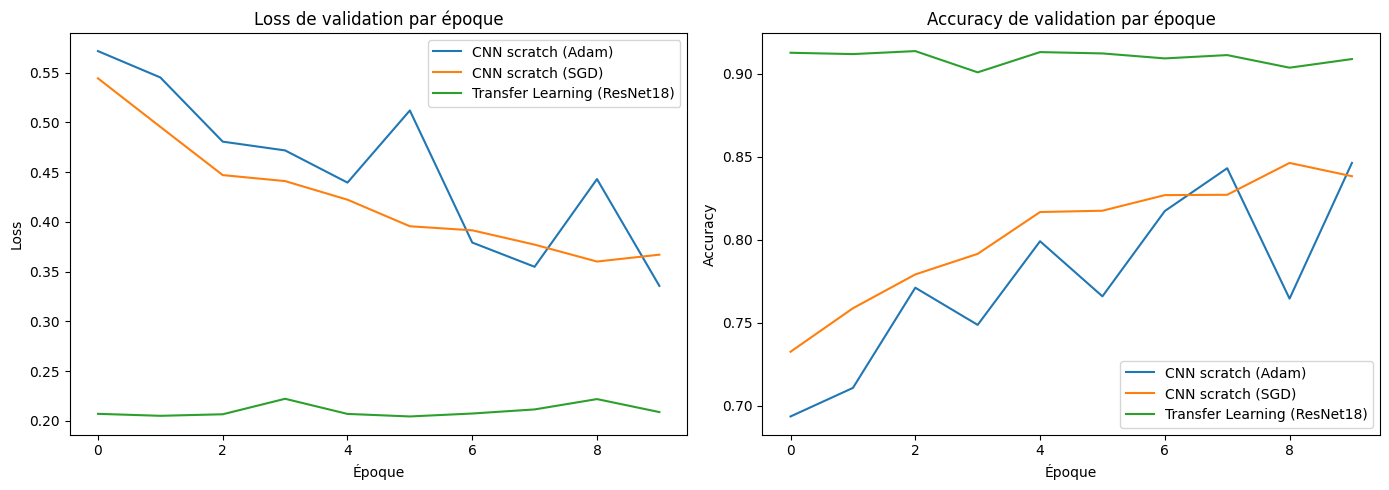

In [15]:
# Comparaison visuelle des 3 entraînements : CNN Adam, CNN SGD (bon lr), et Transfer Learning
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : loss de validation
axes[0].plot(history_scratch["val_loss"], label="CNN scratch (Adam)")
axes[0].plot(history_scratch_sgd2["val_loss"], label="CNN scratch (SGD)")
axes[0].plot(history_transfer["val_loss"], label="Transfer Learning (ResNet18)")
axes[0].set_title("Loss de validation par époque")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Graphique 2 : accuracy de validation
axes[1].plot(history_scratch["val_acc"], label="CNN scratch (Adam)")
axes[1].plot(history_scratch_sgd2["val_acc"], label="CNN scratch (SGD)")
axes[1].plot(history_transfer["val_acc"], label="Transfer Learning (ResNet18)")
axes[1].set_title("Accuracy de validation par époque")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("comparaison_modeles.png")
plt.show()

## **Sauvegarde du meilleur modèle**

Le modèle en transfert learning obtient les meilleurs résultats (~90% d'accuracy) ; on sauvegarde ses poids localement (fichier .pth, non poussé sur GitHub) pour pouvoir le recharger et l'évaluer sans le ré-entraîner.

In [16]:
# Sauvegarde du meilleur modèle (Transfer Learning, le plus performant) — reste local, pas poussé sur GitHub
torch.save(model_transfer.state_dict(), "best_model.pth")
print("Modèle sauvegardé : best_model.pth")

Modèle sauvegardé : best_model.pth


## **Évaluation finale : matrice de confusion**

Le modèle est rechargé depuis le fichier sauvegardé pour prouver qu'il fonctionne bien après sauvegarde, puis évalué sur l'ensemble de validation.

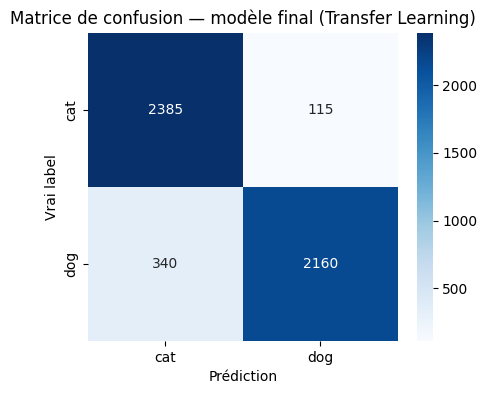

In [17]:
# Matrice de confusion sur le meilleur modèle (rechargé depuis le fichier sauvegardé, pour valider le test final)
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Rechargement du modèle pour prouver qu'il fonctionne bien après sauvegarde
model_final = models.resnet18(weights=None)
num_features = model_final.fc.in_features
model_final.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_features, 2))
model_final.load_state_dict(torch.load("best_model.pth"))
model_final = model_final.to(device)
model_final.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_final(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["cat", "dog"], yticklabels=["cat", "dog"])
plt.xlabel("Prédiction")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion — modèle final (Transfer Learning)")
plt.savefig("matrice_confusion.png")
plt.show()